In [451]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

gen_results = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_real/depth_4_epochs_10000_schedule_VE_sigma_5/generated_mean_std.npz')
gen_samples = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_real/depth_4_epochs_10000_schedule_VE_sigma_5/generated_samples.npz')
real_samples = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_real/depth_4_epochs_10000_schedule_VE_sigma_5/real_samples.npz')
conditional_inputs = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_real/depth_4_epochs_10000_schedule_VE_sigma_5/conditional_inputs.npz')

In [452]:
real = real_samples['arr_0']
pred = gen_results['array1']
print(real.shape)
print(pred.shape)

stds = gen_results['array2']

print(pred.shape)
print(stds.shape)

mae = np.mean(np.abs(real-pred))
print("Mean Absolute Error: " + str(mae))

normalized_mae = mae/np.mean(real)
print("Normalized Mean Absolute Error: " + str(normalized_mae))

mape = np.mean(np.abs(real-pred)/real)
print("Mean Absolute Percent Error: " + str(mape))

new_predict = np.zeros((6))
print(new_predict.shape)

new_predict[0:3] = np.squeeze(pred[1:4])
new_predict[3:] = np.squeeze(pred[5:])

new_real = np.zeros((6))
new_real[0:3] = np.squeeze(real[1:4])
new_real[3:] = np.squeeze(real[5:])

print()

new_mape = np.mean(np.abs(new_real-new_predict)/new_real)
print(new_mape)

(8, 1)
(8, 1)
(8, 1)
(8, 1)
Mean Absolute Error: 0.09377022460103035
Normalized Mean Absolute Error: 0.41848037373208585
Mean Absolute Percent Error: 0.46273265877153225
(6,)

0.34022762728136313


(8,)
(8, 1)


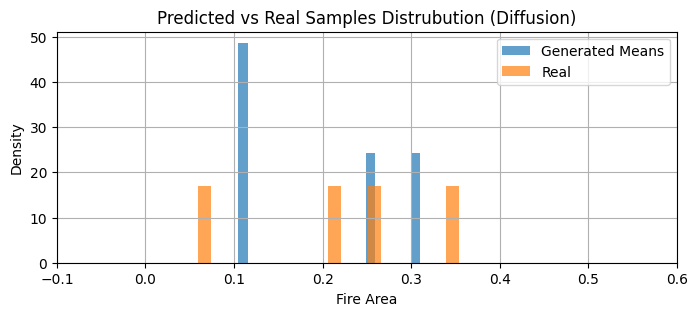

In [453]:
gen = gen_results['array1'].flatten()

print(gen.shape)
print(real.shape)

plt.figure(figsize=(8,3))
plt.title('Predicted vs Real Samples Distrubution (Diffusion)')
plt.hist(gen, bins=20, alpha=0.7, label='Generated Means', density=True)
plt.hist(real, bins=20, alpha=0.7, label='Real', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.xlim((-0.1, 0.6))
plt.ylabel('Density')
plt.grid(True)
plt.show()

(8000,)
(8,)


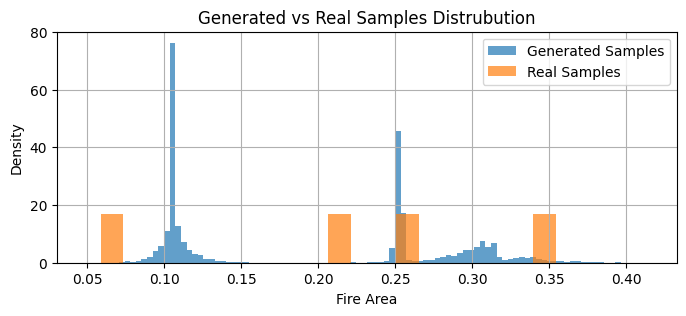

In [454]:
gen = gen_samples['arr_0'].flatten()
real = real_samples['arr_0'].flatten()

print(gen.shape)
print(real.shape)

plt.figure(figsize=(8,3))
plt.title('Generated vs Real Samples Distrubution')
plt.hist(gen, bins=100, alpha=0.7, label='Generated Samples', density=True)
plt.hist(real, bins=20, alpha=0.7, label='Real Samples', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [455]:
means = gen_results['array1']

within_1_std = np.abs(real.flatten() - means.flatten()) <= stds.flatten()
proportions = within_1_std.astype(int)
print(proportions)
print(np.mean(proportions))

[0 0 0 0 0 0 0 0]
0.0


In [456]:
gen_all = gen_samples['arr_0'].reshape(8, 1000)
means = gen_results['array1']
stds = gen_results['array2']
real = real_samples['arr_0']

In [457]:
conditional_inputs = conditional_inputs['arr_0']
col_names = ["forecast_len", "u", "v", "humidity", "temp", "terrain_x", "terrain_y", "terrain_var", "terrain_RMS", "fuel1", "fuel2", "fuel3", "fuel4", "fuel5", "fuel6", "fuel7", "fuel8", "fuel9", "fuel10", "fuel11", "fuel12","fuel13", "fuel14"]
df = pd.DataFrame(conditional_inputs, columns=col_names)

df['forecast_len'] = df['forecast_len'] * 50
print("fuel 2")
print(df['fuel2'])
print("-"*30)

# print("fuel 3")
# print(df['fuel3'])
# print("-"*30)

print("fuel 4")
print(df['fuel4'])
print("-"*30)

fuel 2
0    0.000788
1    0.021352
2    0.018466
3    0.003527
4    0.000788
5    0.021352
6    0.018466
7    0.003527
Name: fuel2, dtype: float32
------------------------------
fuel 4
0    0.000000
1    0.000000
2    0.000000
3    0.005377
4    0.000000
5    0.000000
6    0.000000
7    0.005377
Name: fuel4, dtype: float32
------------------------------


In [458]:
df

,forecast_len,u,v,humidity,temp,terrain_x,terrain_y,terrain_var,terrain_RMS,fuel1,...,fuel5,fuel6,fuel7,fuel8,fuel9,fuel10,fuel11,fuel12,fuel13,fuel14
0,28.133333,0.695001,0.385847,0.274469,0.637824,0.589162,0.463941,0.320502,0.502513,0.434645,...,0.066655,0.000000,0.120853,0.000000,0.000000,0.218261,0.0,0.002486,0.000000,0.156312
1,30.700001,0.310081,0.069016,0.264209,0.423227,0.567245,0.007426,0.500740,0.902938,0.281366,...,0.052377,0.018327,0.022973,0.001792,0.000000,0.005319,0.0,0.000000,0.596495,0.000000
2,32.600002,0.654808,0.441763,0.087888,0.806576,0.609722,0.438086,0.366991,0.378585,0.517141,...,0.108284,0.015147,0.008305,0.303178,0.018611,0.010869,0.0,0.000000,0.000000,0.000000
3,36.250000,0.396298,0.279471,0.424173,0.488571,0.443778,0.387653,0.230446,0.358215,0.174905,...,0.076245,0.073555,0.073338,0.010184,0.001792,0.020609,0.0,0.000000,0.329736,0.230733
4,27.266666,0.717395,0.302005,0.314222,0.613147,0.589162,0.463941,0.320502,0.502513,0.434645,...,0.066655,0.000000,0.120853,0.000000,0.000000,0.218261,0.0,0.002486,0.000000,0.156312
5,30.566666,0.303492,0.057553,0.266342,0.421433,0.567245,0.007426,0.500740,0.902938,0.281366,...,0.052377,0.018327,0.022973,0.001792,0.000000,0.005319,0.0,0.000000,0.596495,0.000000
6,32.333332,0.655679,0.438096,0.087545,0.806422,0.609722,0.438086,0.366991,0.378585,0.517141,...,0.108284,0.015147,0.008305,0.303178,0.018611,0.010869,0.0,0.000000,0.000000,0.000000
7,36.149998,0.393899,0.276997,0.419265,0.490101,0.443778,0.387653,0.230446,0.358215,0.174905,...,0.076245,0.073555,0.073338,0.010184,0.001792,0.020609,0.0,0.000000,0.329736,0.230733


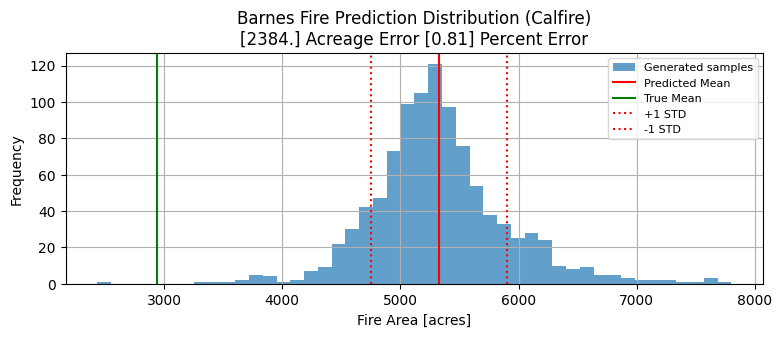

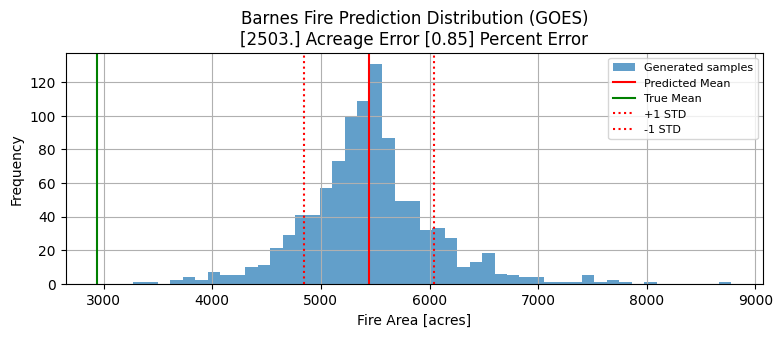

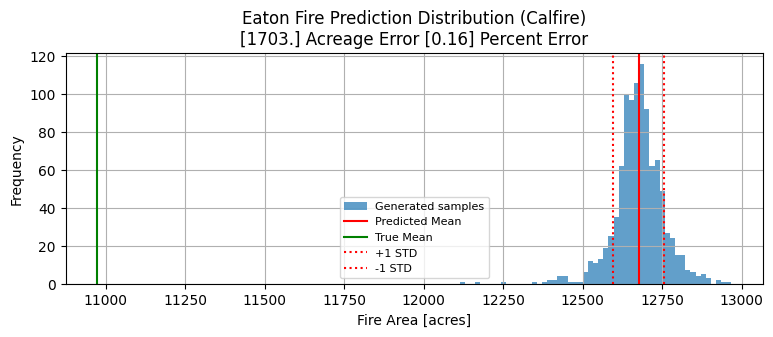

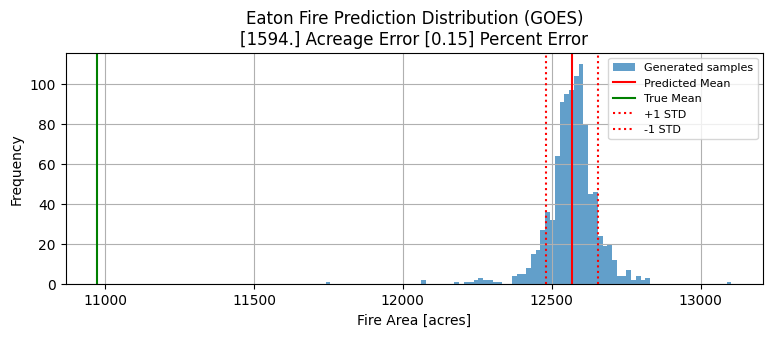

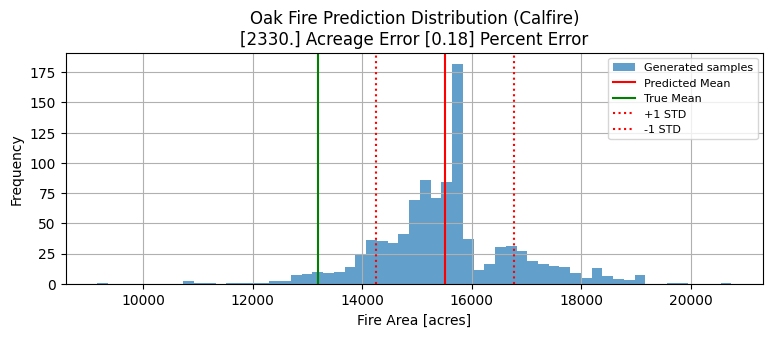

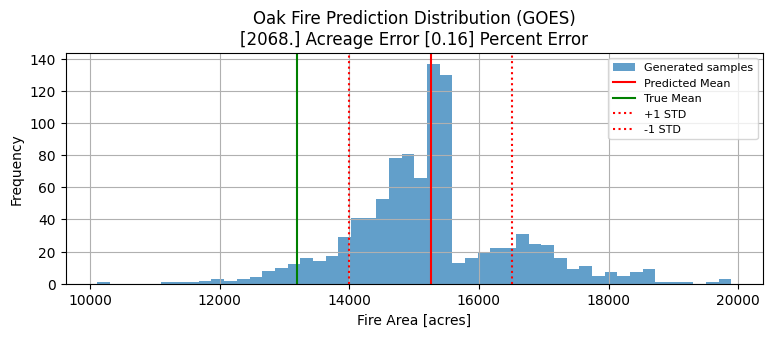

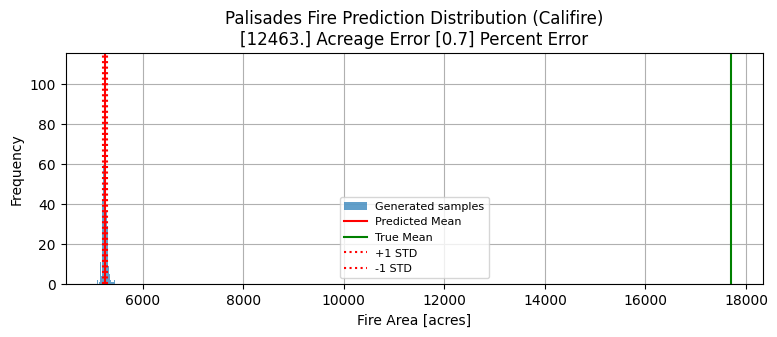

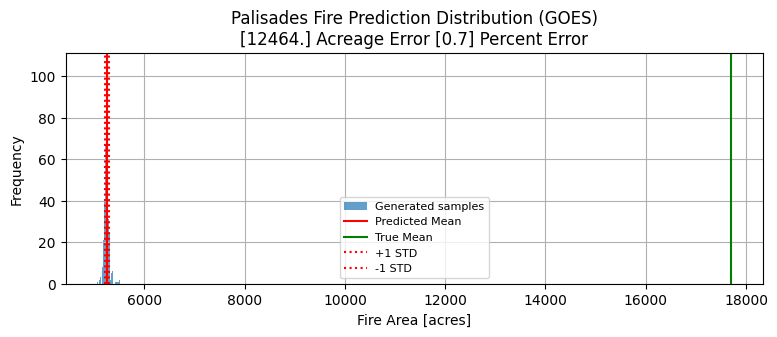

In [459]:
percent_error = np.round(np.abs((means[0]-real[0])/real[0]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Barnes Fire Prediction Distribution (Calfire)\n' + str(np.round(np.abs(real[0]-means[0])*50000)) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[0]*50000, bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[0]*50000, color='red', label='Predicted Mean')
plt.axvline(real[0]*50000, color='green', label='True Mean')
plt.axvline(means[0]*50000+stds[0]*50000, color='red', label='+1 STD', linestyle=':')
plt.axvline(means[0]*50000-stds[0]*50000, color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[4]-real[4])/real[4]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Barnes Fire Prediction Distribution (GOES)\n' + str(np.round(np.abs(real[4]-means[4])*50000)) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[4]*50000, bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[4]*50000, color='red', label='Predicted Mean')
plt.axvline(real[4]*50000, color='green', label='True Mean')
plt.axvline(means[4]*50000+stds[4]*50000, color='red', label='+1 STD', linestyle=':')
plt.axvline(means[4]*50000-stds[4]*50000, color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[1]-real[1])/real[1]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Eaton Fire Prediction Distribution (Calfire)\n' + str(np.round(np.abs(real[1]-means[1])*50000)) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[1]*50000, bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[1]*50000, color='red', label='Predicted Mean')
plt.axvline(real[1]*50000, color='green', label='True Mean')
plt.axvline(means[1]*50000+stds[1]*50000, color='red', label='+1 STD', linestyle=':')
plt.axvline(means[1]*50000-stds[1]*50000, color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[5]-real[5])/real[5]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Eaton Fire Prediction Distribution (GOES)\n' + str(np.round(np.abs(real[5]-means[5])*50000)) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[5]*50000, bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[5]*50000, color='red', label='Predicted Mean')
plt.axvline(real[5]*50000, color='green', label='True Mean')
plt.axvline(means[5]*50000+stds[5]*50000, color='red', label='+1 STD', linestyle=':')
plt.axvline(means[5]*50000-stds[5]*50000, color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[2]-real[2])/real[2]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Oak Fire Prediction Distribution (Calfire)\n' + str(np.round(np.abs(real[2]-means[2])*50000)) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[2]*50000, bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[2]*50000, color='red', label='Predicted Mean')
plt.axvline(real[2]*50000, color='green', label='True Mean')
plt.axvline(means[2]*50000+stds[2]*50000, color='red', label='+1 STD', linestyle=':')
plt.axvline(means[2]*50000-stds[2]*50000, color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[6]-real[6])/real[6]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Oak Fire Prediction Distribution (GOES)\n' + str(np.round(np.abs(real[6]-means[6])*50000)) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[6]*50000, bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[6]*50000, color='red', label='Predicted Mean')
plt.axvline(real[6]*50000, color='green', label='True Mean')
plt.axvline(means[6]*50000+stds[6]*50000, color='red', label='+1 STD', linestyle=':')
plt.axvline(means[6]*50000-stds[6]*50000, color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[3]-real[3])/real[3]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Palisades Fire Prediction Distribution (Califire)\n' + str(np.round(np.abs(real[3]-means[3])*50000)) + ' Acreage Error '  + str(percent_error) + ' Percent Error')
plt.hist(gen_all[3]*50000, bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[3]*50000, color='red', label='Predicted Mean')
plt.axvline(real[3]*50000, color='green', label='True Mean')
plt.axvline(means[3]*50000+stds[3]*50000, color='red', label='+1 STD', linestyle=':')
plt.axvline(means[3]*50000-stds[3]*50000, color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[7]-real[7])/real[7]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Palisades Fire Prediction Distribution (GOES)\n' + str(np.round(np.abs(real[7]-means[7])*50000)) + ' Acreage Error '  + str(percent_error) + ' Percent Error')
plt.hist(gen_all[7]*50000, bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[7]*50000, color='red', label='Predicted Mean')
plt.axvline(real[7]*50000, color='green', label='True Mean')
plt.axvline(means[7]*50000+stds[7]*50000, color='red', label='+1 STD', linestyle=':')
plt.axvline(means[7]*50000-stds[7]*50000, color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()